In [1]:
import os
import numpy as np
import math
import pandas as pd
import seaborn as sns
import torch
os.environ["KERAS_BACKEND"] = "torch"
import keras
from keras.callbacks import Callback
from datamodules import data_processors
from sklearn.preprocessing import StandardScaler
import sys
print(sys.version)
from rusmodules import eigenvals, geometry
from rusmodules.inverse import get_constants

(null): No such file or directory
(null): No such file or directory
(null): No such file or directory
(null): No such file or directory


3.14.6 (main, Jun 10 2026, 10:03:53) [GCC 15.2.0]


In [2]:
import matplotlib
matplotlib.rcParams.update({
  #"text.usetex": True,
  "font.family": "serif",
  "font.serif": ["NewComputerModernMath"],
  "mathtext.fontset": "cm",
  "pdf.fonttype": 42,
  "ps.fonttype": 42,
  "font.size": 11,
  "axes.labelsize": "x-large",
  "xtick.labelsize": 13,
  "ytick.labelsize": 13,
  "legend.fontsize": 13,
  "axes.linewidth": 0.8,
  "lines.linewidth": 1.2,
  "lines.markersize": 3.5,
})
import matplotlib.pyplot as plt
%matplotlib inline
#plt.style.use('ggplot')

In [3]:
n_pow = 20
def custom_activation(x):
    return (1/n_pow) * torch.log((1 + torch.exp(n_pow * x)) / (1 + torch.exp(n_pow * (x - 1))))
#fin función

# Wrap the function in a Keras custom layer
@keras.saving.register_keras_serializable()
class CustomActivationLayer(keras.layers.Layer):
    def __init__(self, **kwargs):
        super(CustomActivationLayer, self).__init__(**kwargs)
    
    def call(self, inputs):
        # Ensure inputs are Torch tensors
        inputs = torch.tensor(inputs) if not isinstance(inputs, torch.Tensor) else inputs
        return custom_activation(inputs)
    #fin función
#fin clase
path_to_current_model_cubic = "models/cubico_L4.keras"
modelo_cubico = keras.models.load_model(path_to_current_model_cubic)
path_to_current_model_isotropic = "models/isotropico_act_custom_6.keras"
modelo_isotropico = keras.models.load_model(path_to_current_model_isotropic)
stats_modelo_cubico = pd.read_csv(path_to_current_model_cubic[:-6]+"_stats.csv")
stats_modelo_cubico = stats_modelo_cubico.set_index("Unnamed: 0")
dic_stats = dict(map(lambda x: (x, dict(map(lambda y: (y, stats_modelo_cubico[y][x]),stats_modelo_cubico.keys()))), ["mean", "std"]))
modelo_datos = {"model": modelo_cubico, **dic_stats}

N_data = 200
Ng = 6
shape_def = "Parallelepiped"
N_eig_iso = 5
N_eig_cubic = 20
features_cubic = ["eta", "beta"] + list(map(lambda x: "x_" + str(x), range(N_eig_cubic + 1)))
features_iso = ["eta", "beta"] + list(map(lambda x: "eig_moño_" + str(x+1), range(N_eig_iso)))

In [4]:
geometries = geometry.generate_sphere_surface_points_random(N_data, 0.61*np.pi, np.pi)
geo_df = pd.DataFrame()
geo_df["eta"] = geometries[:,0]
geo_df["beta"] = geometries[:, 1]
print(max(geo_df["eta"])/np.pi)
print(max(geo_df["beta"])/np.pi)

0.6090691128885788
0.9976208492006916


In [5]:
geo_df

,eta,beta
0,0.530880,2.721371
1,0.173485,3.123044
2,1.560232,2.742148
3,1.706458,2.361021
4,0.181892,0.406425
...,...,...
195,1.361039,0.914803
196,1.196006,1.801519
197,1.730419,0.540048
198,0.849012,0.266024


In [6]:
M_max = 150 #GPa
datos_iso = pd.DataFrame()
datos_cubic = pd.DataFrame()
datos_iso["K"] = np.random.uniform(10, M_max, N_data)
datos_iso["G"] = np.random.uniform(10, M_max, N_data)
datos_cubic["K"] = np.random.uniform(10, M_max, N_data)
datos_cubic["mu"] = np.random.uniform(10, M_max, N_data)
datos_cubic["a"] = np.random.uniform(10, M_max, N_data)
datos_cubic["C11"] = datos_cubic["K"] + 2*datos_cubic["a"]
datos_cubic["C12"] = datos_cubic["K"] - datos_cubic["a"]
datos_cubic["C44"] = datos_cubic["mu"]
datos_iso["phi_K"] = np.arctan(datos_iso["G"]/datos_iso["K"])
datos_cubic["phi_K"] = np.arctan(np.sqrt((datos_cubic["a"])**2 + (datos_cubic["mu"])**2)/datos_cubic["K"])
datos_cubic["phi_a"] = np.arctan(datos_cubic["mu"]/datos_cubic["a"])
datos_iso = pd.concat((datos_iso, geo_df), axis = 1)
datos_cubic = pd.concat((datos_cubic, geo_df), axis = 1)

In [7]:
datos_iso

,K,G,phi_K,eta,beta
0,124.814597,116.510419,0.751001,0.530880,2.721371
1,43.468837,105.326083,1.179384,0.173485,3.123044
2,145.245127,76.391606,0.484191,1.560232,2.742148
3,88.299722,41.531798,0.439648,1.706458,2.361021
4,92.075532,147.296927,1.012124,0.181892,0.406425
...,...,...,...,...,...
195,103.266579,68.477958,0.585542,1.361039,0.914803
196,83.868318,13.432720,0.158816,1.196006,1.801519
197,36.736560,14.433050,0.374353,1.730419,0.540048
198,104.991155,24.268854,0.227162,0.849012,0.266024


In [8]:
datos_cubic

,K,mu,a,C11,C12,C44,phi_K,phi_a,eta,beta
0,43.411773,79.372186,56.053698,155.519168,-12.641925,79.372186,1.150638,0.955912,0.530880,2.721371
1,99.491332,134.685102,121.657321,342.805973,-22.165989,134.685102,1.069355,0.836176,0.173485,3.123044
2,127.301048,133.611153,53.135432,233.571912,74.165615,133.611153,0.846145,1.192285,1.560232,2.742148
3,22.469576,113.028222,53.025042,128.519661,-30.555466,113.028222,1.392727,1.132147,1.706458,2.361021
4,10.511172,105.344486,119.055563,248.622299,-108.544391,105.344486,1.504772,0.724373,0.181892,0.406425
...,...,...,...,...,...,...,...,...,...,...
195,138.877221,49.096663,123.001958,384.881137,15.875263,49.096663,0.761671,0.379776,1.361039,0.914803
196,125.903274,59.313527,55.604248,237.111770,70.299026,59.313527,0.573378,0.817665,1.196006,1.801519
197,133.252080,61.918729,97.272551,327.797183,35.979529,61.918729,0.713330,0.566861,1.730419,0.540048
198,91.002059,81.237933,31.276996,153.556052,59.725063,81.237933,0.763211,1.203283,0.849012,0.266024


In [9]:
datos_cubic["C11_pred"] = 0.0
datos_cubic["C12_pred"] = 0.0
datos_cubic["C44_pred"] = 0.0

datos_iso["K_pred"] = 0.0
datos_iso["G_pred"] = 0.0
for i in range(N_eig_iso):
  datos_iso[f"eig_{i}"] = 0.0
  datos_iso[f"eig_moño_{i}"] = 0.0

In [10]:
for i in datos_iso.index:
  Ki = datos_iso.at[i, "K"]
  Gi = datos_iso.at[i, "G"]
  eta_g = datos_iso.at[i, "eta"]
  beta_g = datos_iso.at[i, "beta"]
  C_iso = eigenvals.get_elastic_constants({"K": Ki, "mu": Gi})
  eigs_iso = eigenvals.get_eigenvalues(Ng, C_iso, eta_g, beta_g, shape_def)["eig"][:N_eig_iso + 1]
  for j in range(len(eigs_iso)):
    datos_iso.at[i, f"eig_{j}"] = eigs_iso[j]
    if j == 0:
      datos_iso.at[i, f"eig_moño_{j}"] = eigs_iso[j]
    elif j == 1:
      datos_iso.at[i, f"eig_moño_{j}"] = 1/eigs_iso[j]
    else:
      datos_iso.at[i, f"eig_moño_{j}"] = eigs_iso[j-1]/eigs_iso[j]

datos_iso["phi_K_pred"] = modelo_isotropico.predict(datos_iso[features_iso])*(np.pi/2)
  

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step  


In [11]:
datos_iso[["phi_K", "phi_K_pred", "K", "G", "eig_0"]]

,phi_K,phi_K_pred,K,G,eig_0
0,0.751001,0.807793,124.814597,116.510419,9.507360
1,1.179384,0.830463,43.468837,105.326083,0.100552
2,0.484191,0.435588,145.245127,76.391606,202.216435
3,0.439648,0.426752,88.299722,41.531798,103.988778
4,1.012124,0.898622,92.075532,147.296927,0.000859
...,...,...,...,...,...
195,0.585542,0.653918,103.266579,68.477958,13.432872
196,0.158816,0.195262,83.868318,13.432720,10.215783
197,0.374353,0.348622,36.736560,14.433050,1.152135
198,0.227162,0.219031,104.991155,24.268854,0.031761


In [12]:
for i in datos_iso.index:
  phi_K_p = datos_iso.at[i, "phi_K_pred"]
  eta_g = datos_iso.at[i, "eta"]
  beta_g = datos_iso.at[i, "beta"]
  eig0_ref_l = eigenvals.forward_standard({"phi_K": phi_K_p}, eta_g, beta_g, "Parallelepiped", Ng)["eig"]
  datos_iso.at[i, "eig_ref_0"] = eig0_ref_l[0]
  datos_iso.at[i, "eig_ref_1"] = eig0_ref_l[1]
  datos_iso.at[i, "eig_ref_2"] = eig0_ref_l[2]
  datos_iso.at[i, "eig_ref_3"] = eig0_ref_l[3]
  datos_iso.at[i, "eig_ref_4"] = eig0_ref_l[4]
  datos_iso.at[i, "eig_ref_5"] = eig0_ref_l[5]

datos_iso["M_pred"] = 1/6*(datos_iso["eig_0"]/datos_iso["eig_ref_0"] * ( 1+
                              datos_iso["eig_1"]/datos_iso["eig_ref_1"] +
                              datos_iso["eig_2"]/datos_iso["eig_ref_2"] +
                              datos_iso["eig_3"]/datos_iso["eig_ref_3"] +
                              datos_iso["eig_4"]/datos_iso["eig_ref_4"] +
                              datos_iso["eig_5"]/datos_iso["eig_ref_5"]))
datos_iso["K_pred"] = datos_iso["M_pred"]*np.cos(datos_iso["phi_K_pred"])
datos_iso["G_pred"] = datos_iso["M_pred"]*np.sin(datos_iso["phi_K_pred"])

In [13]:
datos_iso[["K", "K_pred", "G", "G_pred"]]

,K,K_pred,G,G_pred
0,124.814597,113.825131,116.510419,119.041070
1,43.468837,75.922061,105.326083,83.092815
2,145.245127,163.335455,76.391606,76.016611
3,88.299722,91.161108,41.531798,41.450530
4,92.075532,111.350429,147.296927,139.922880
...,...,...,...,...
195,103.266579,90.995214,68.477958,69.739242
196,83.868318,68.245648,13.432720,13.497753
197,36.736560,39.400111,14.433050,14.320656
198,104.991155,108.775068,24.268854,24.213592


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


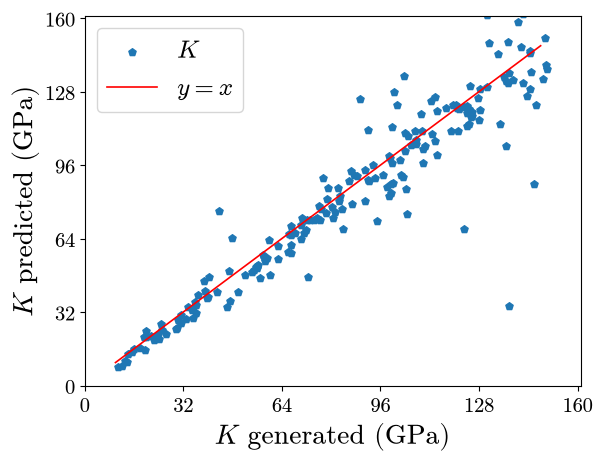

In [46]:
fig_K = plt.figure()
ax1 =fig_K.add_subplot(111)
line_color = "red"
labels_fontsize = 20
ref1 = range(int(min(datos_iso["K"])), int(max(datos_iso["K"])))
ax1.scatter(datos_iso["K"], datos_iso["K_pred"], marker="p", s=30)
ax1.plot(list(ref1), list(ref1), color = line_color)
ax1.set_xlabel(r"$K$ generated (GPa)", fontsize = labels_fontsize)
ax1.set_ylabel(r"$K$ predicted (GPa)", fontsize = labels_fontsize)
ax1.set_ylim(min(datos_iso["K_pred"]) - 5, 161)
ax1.set_xlim(min(datos_iso["K"]) - 5, 161)
ticks = np.linspace(0, 160, 6) 
ax1.set_xticks(ticks)
ax1.set_yticks(ticks)
ax1.tick_params(axis='x', labelsize=15)
ax1.tick_params(axis='y', labelsize=15)
ax1.legend([r"$K$", r"$y = x$"], fontsize = 18)
plt.savefig("../Thesis_Docs/pictures/figXX_K.pdf", bbox_inches="tight", pad_inches=0)

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


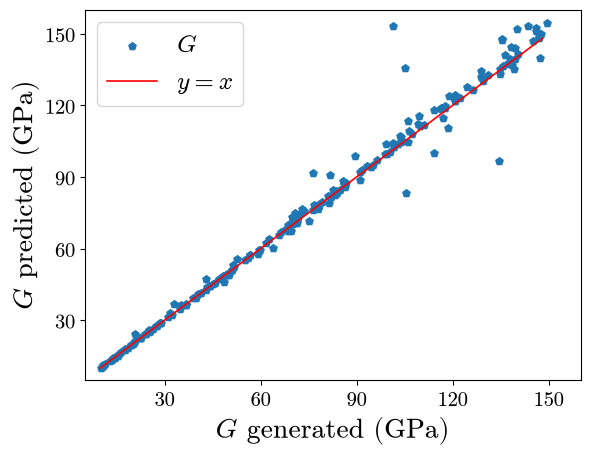

In [37]:
fig_G = plt.figure()
ax1 =fig_G.add_subplot(111)
line_color = "red"
labels_fontsize = 20
ref1 = range(int(min(datos_iso["G"])), int(max(datos_iso["G"])))
ax1.scatter(datos_iso["G"], datos_iso["G_pred"], marker="p", s=30)
ax1.plot(list(ref1), list(ref1), color = line_color)
ax1.set_xlabel(r"$G$ generated (GPa)", fontsize = labels_fontsize)
ax1.set_ylabel(r"$G$ predicted (GPa)", fontsize = labels_fontsize)
ax1.set_ylim(min(datos_iso["G"]), max(datos_iso["G"]))
ax1.tick_params(axis='x', labelsize=15)
ax1.tick_params(axis='y', labelsize=15)
ticks = np.linspace(0, 150, 6) 
ax1.set_xticks(ticks)
ax1.set_yticks(ticks)
ax1.set_ylim(min(datos_iso["G_pred"]) - 5, 160)
ax1.set_xlim(min(datos_iso["G"]) - 5 , 160)
ax1.legend([r"$G$", r"$y = x$"], fontsize = 18)
plt.savefig("../Thesis_Docs/pictures/figXX_G.pdf", bbox_inches="tight", pad_inches=0)

In [16]:
for i in datos_cubic.index:
  Ki = datos_cubic.at[i, "K"]
  mui = datos_cubic.at[i, "mu"]
  ai = datos_cubic.at[i, "a"]
  eta_g = datos_cubic.at[i, "eta"]
  beta_g = datos_cubic.at[i, "beta"]
  C_cubic = eigenvals.get_elastic_constants({"K": Ki, "mu": mui, "a": ai})
  eigs_cubic = eigenvals.get_eigenvalues(Ng, C_cubic, eta_g, beta_g, shape_def)["eig"][:N_eig_cubic]
  C_predicted = get_constants(eigs_cubic, eta_g, beta_g, modelo_datos)
  datos_cubic.at[i, "C11_pred"] = C_predicted["C00"]
  datos_cubic.at[i, "C12_pred"] = C_predicted["C01"]
  datos_cubic.at[i, "C44_pred"] = C_predicted["C33"]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━

In [17]:
datos_cubic.dropna()

,K,mu,a,C11,C12,C44,phi_K,phi_a,eta,beta,C11_pred,C12_pred,C44_pred
0,43.411773,79.372186,56.053698,155.519168,-12.641925,79.372186,1.150638,0.955912,0.530880,2.721371,154.173285,-0.601903,78.368363
1,99.491332,134.685102,121.657321,342.805973,-22.165989,134.685102,1.069355,0.836176,0.173485,3.123044,377.430274,-49.767438,118.631791
2,127.301048,133.611153,53.135432,233.571912,74.165615,133.611153,0.846145,1.192285,1.560232,2.742148,238.964366,81.432136,134.156556
3,22.469576,113.028222,53.025042,128.519661,-30.555466,113.028222,1.392727,1.132147,1.706458,2.361021,128.304529,-29.960579,111.708024
4,10.511172,105.344486,119.055563,248.622299,-108.544391,105.344486,1.504772,0.724373,0.181892,0.406425,188.424636,-66.894751,65.226942
...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,138.877221,49.096663,123.001958,384.881137,15.875263,49.096663,0.761671,0.379776,1.361039,0.914803,379.800066,16.179609,49.703206
196,125.903274,59.313527,55.604248,237.111770,70.299026,59.313527,0.573378,0.817665,1.196006,1.801519,237.465442,66.470740,58.336414
197,133.252080,61.918729,97.272551,327.797183,35.979529,61.918729,0.713330,0.566861,1.730419,0.540048,330.710448,52.846816,62.910482
198,91.002059,81.237933,31.276996,153.556052,59.725063,81.237933,0.763211,1.203283,0.849012,0.266024,151.811926,56.891331,80.772890


In [18]:
datos_graph = datos_cubic.dropna()

In [19]:
print(datos_graph[["C11", "C11_pred", "C12", "C12_pred", "C44", "C44_pred"]])

            C11    C11_pred         C12   C12_pred         C44    C44_pred
0    155.519168  154.173285  -12.641925  -0.601903   79.372186   78.368363
1    342.805973  377.430274  -22.165989 -49.767438  134.685102  118.631791
2    233.571912  238.964366   74.165615  81.432136  133.611153  134.156556
3    128.519661  128.304529  -30.555466 -29.960579  113.028222  111.708024
4    248.622299  188.424636 -108.544391 -66.894751  105.344486   65.226942
..          ...         ...         ...        ...         ...         ...
195  384.881137  379.800066   15.875263  16.179609   49.096663   49.703206
196  237.111770  237.465442   70.299026  66.470740   59.313527   58.336414
197  327.797183  330.710448   35.979529  52.846816   61.918729   62.910482
198  153.556052  151.811926   59.725063  56.891331   81.237933   80.772890
199  102.234399  102.788219  -18.356566 -18.762962   43.833349   43.636866

[200 rows x 6 columns]


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


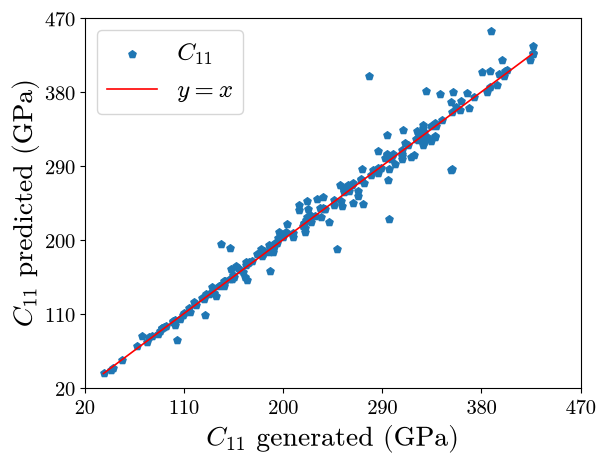

In [34]:
fig_C11 = plt.figure()
ax1 =fig_C11.add_subplot(111)
line_color = "red"
labels_fontsize = 20
ref1 = range(int(min(datos_graph["C11"])), int(max(datos_graph["C11"])))
ax1.scatter(datos_graph["C11"], datos_graph["C11_pred"], marker="p", s=30)
ax1.plot(list(ref1), list(ref1), color = line_color)
ax1.set_xlabel(r"$C_{11}$ generated (GPa)", fontsize = labels_fontsize)
ax1.set_ylabel(r"$C_{11}$ predicted (GPa)", fontsize = labels_fontsize)
ax1.set_ylim(min(datos_graph["C11_pred"]) - 7, max(datos_graph["C11_pred"]) + 7)
ax1.set_xlim(min(datos_graph["C11_pred"]) - 7, max(datos_graph["C11_pred"]) + 7)
ticks = np.linspace(20, 470, 6) 
ax1.set_xticks(ticks)
ax1.set_yticks(ticks)
ax1.tick_params(axis='x', labelsize=15)
ax1.tick_params(axis='y', labelsize=15)
ax1.legend([r"$C_{11}$", r"$y = x$"], fontsize = 18)
plt.savefig("../Thesis_Docs/pictures/figXX_C11.pdf", bbox_inches="tight", pad_inches=0)

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


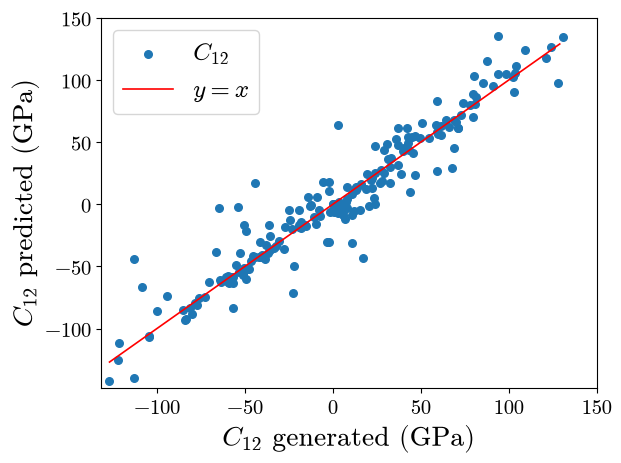

In [41]:
fig_C12 = plt.figure()
ax1 =fig_C12.add_subplot(111)
line_color = "red"
labels_fontsize = 20
ref1 = range(int(min(datos_graph["C12"])), int(max(datos_graph["C12"])))
ax1.scatter(datos_graph["C12"], datos_graph["C12_pred"], marker="o", s=30)
ax1.plot(list(ref1), list(ref1), color = line_color)
ax1.set_xlabel(r"$C_{12}$ generated (GPa)", fontsize = labels_fontsize)
ax1.set_ylabel(r"$C_{12}$ predicted (GPa)", fontsize = labels_fontsize)
ax1.set_ylim(min(datos_graph["C12_pred"]) - 5, max(datos_graph["C12_pred"]) + 10)
ax1.set_xlim(min(datos_graph["C12"]) - 5, max(datos_graph["C12_pred"]) + 10)
ticks = np.linspace(-100, 150, 6) 
ax1.set_xticks(ticks)
ax1.set_yticks(ticks)
ax1.tick_params(axis='x', labelsize=15)
ax1.tick_params(axis='y', labelsize=15)
ax1.legend([r"$C_{12}$", r"$y = x$"], fontsize = 18)
plt.savefig("../Thesis_Docs/pictures/figXX_C12.pdf", bbox_inches="tight", pad_inches=0)

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


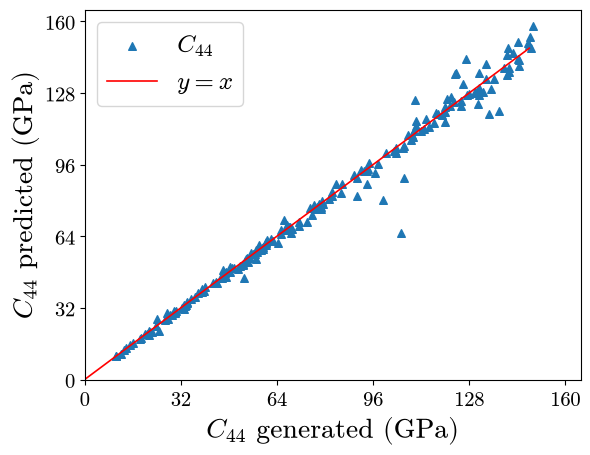

In [33]:
fig_C44 = plt.figure()
ax1 =fig_C44.add_subplot(111)
line_color = "red"
labels_fontsize = 20
ref1 = range(int(max(datos_graph["C44"])))
ax1.scatter(datos_graph["C44"], datos_graph["C44_pred"], marker="^", s=30)
ax1.plot(list(ref1), list(ref1), color = line_color)
ax1.set_xlabel(r"$C_{44}$ generated (GPa)", fontsize = labels_fontsize)
ax1.set_ylabel(r"$C_{44}$ predicted (GPa)", fontsize = labels_fontsize)
ax1.set_ylim(min(datos_graph["C44_pred"]) - 5, max(datos_graph["C44_pred"]) + 7)
ax1.set_xlim(min(datos_graph["C44_pred"]) - 5, max(datos_graph["C44_pred"]) + 7)
ax1.tick_params(axis='x', labelsize=15)
ax1.tick_params(axis='y', labelsize=15)
ticks = np.linspace(0, 160, 6) 
ax1.set_xticks(ticks)
ax1.set_yticks(ticks)
ax1.legend([r"$C_{44}$", r"$y = x$"], fontsize = 18)
plt.savefig("../Thesis_Docs/pictures/figXX_C44.pdf", bbox_inches="tight", pad_inches=0)